# Installation

In [34]:
pip install torch torchvision matplotlib seaborn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Import Libraries

In [35]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from collections import Counter
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Device Configuration

In [36]:
torch.backends.cudnn.benchmark = True
device = torch.device( "mps" if torch.backends.mps.is_available() else "cpu")

# Hyperparameters

In [37]:
BATCH_SIZE= 64
LR = 3e-4
EPOCHS = 55
NUM_CLASSES = 7

# Data Preprocessing

In [38]:
train_transform = transforms.Compose([ #Augmentation
    transforms.Grayscale(1),
    transforms.Resize((48,48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Dataset Visualization

## Load the dataset

In [39]:
train_dataset = datasets.ImageFolder(
    "/Users/helen/archive/train",
    transform = train_transform
    )

test_dataset = datasets.ImageFolder(
    "/Users/helen/archive/test",
    transform = test_transform
)

train_loader = DataLoader(
    train_dataset,batch_size = BATCH_SIZE,
    shuffle=True, num_workers=2,pin_memory=True
)

test_loader = DataLoader(
    test_dataset,batch_size = BATCH_SIZE,
    shuffle=False,num_workers=2,pin_memory=True
)

## Sample images visualization

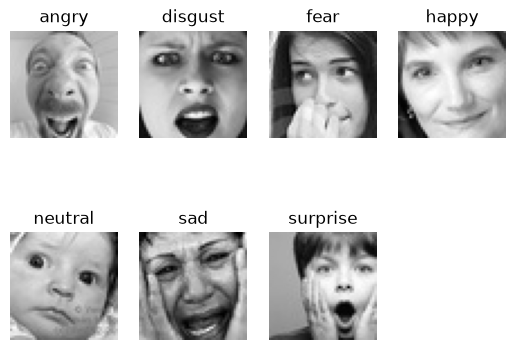

<Figure size 1200x600 with 0 Axes>

In [40]:
classes = train_dataset.classes
root_dir = train_dataset.root

for i, emotion in enumerate(classes):
    class_dir = os.path.join(root_dir, emotion)
    img_name = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, img_name)
    img = plt.imread(img_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(emotion)
    plt.axis("off")

plt.figure(figsize=(12,6))
plt.tight_layout()
plt.show()

In [41]:
labels = [label for _, label in train_dataset.samples]
counts = Counter(labels)

print(counts)

Counter({3: 7215, 4: 4965, 5: 4830, 2: 4097, 0: 3995, 6: 3171, 1: 436})


In [42]:
for i, emotion in enumerate(train_dataset.classes):
    print(emotion, counts[i])

angry 3995
disgust 436
fear 4097
happy 7215
neutral 4965
sad 4830
surprise 3171


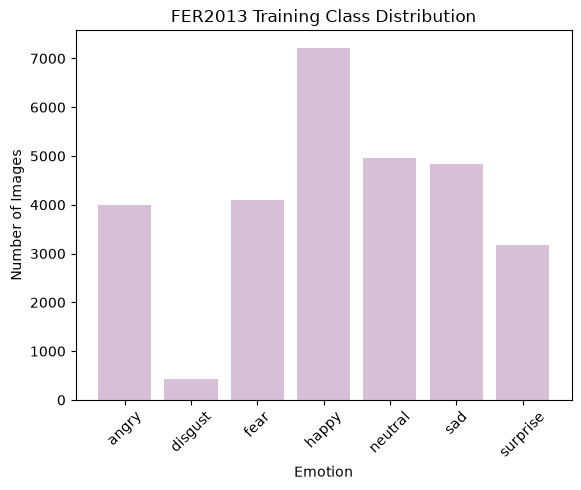

In [43]:
plt.bar(
    train_dataset.classes,
    [counts[i] for i in range(len(train_dataset.classes))],
    color="thistle"
)

plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.title("FER2013 Training Class Distribution")

plt.xticks(rotation=45)
plt.show()

# CNN(baseline)

In [44]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(64, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),

            nn.Conv2d(256, 512, 3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(512, 7)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
        
model = ImprovedCNN().to(device)

# Training & Testing Loop

In [45]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [46]:
train_losses = []
train_accs = []
test_losses = []
test_accs = []

best_acc = 0.0

for epoch in range(EPOCHS):

    # Training Loop

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)



    # Testing Loop
  
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.inference_mode():

        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    test_loss = total_loss / len(test_loader)
    test_acc = correct / total

    test_losses.append(test_loss)
    test_accs.append(test_acc)

    scheduler.step(test_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train_loss: {train_loss:.4f} | "
        f"Train_acc: {train_acc:.4f} | "
        f"Test_loss: {test_loss:.4f} | "
        f"Test_acc: {test_acc:.4f}"
    )

    if test_acc > best_acc:
        best_acc = test_acc
        
        torch.save(
            model.state_dict(),
            "best_improved_cnn.pth"
            )

        print(f"Best model saved: {best_acc:.4f}")

Epoch [1/55] | Train_loss: 1.6463 | Train_acc: 0.3632 | Test_loss: 1.4305 | Test_acc: 0.4739
Best model saved: 0.4739
Epoch [2/55] | Train_loss: 1.4097 | Train_acc: 0.4870 | Test_loss: 1.3128 | Test_acc: 0.5330
Best model saved: 0.5330
Epoch [3/55] | Train_loss: 1.3233 | Train_acc: 0.5300 | Test_loss: 1.3170 | Test_acc: 0.5306
Epoch [4/55] | Train_loss: 1.2702 | Train_acc: 0.5574 | Test_loss: 1.3317 | Test_acc: 0.5195
Epoch [5/55] | Train_loss: 1.2377 | Train_acc: 0.5692 | Test_loss: 1.3057 | Test_acc: 0.5450
Best model saved: 0.5450
Epoch [6/55] | Train_loss: 1.2120 | Train_acc: 0.5793 | Test_loss: 1.1853 | Test_acc: 0.5894
Best model saved: 0.5894
Epoch [7/55] | Train_loss: 1.1922 | Train_acc: 0.5899 | Test_loss: 1.1533 | Test_acc: 0.6049
Best model saved: 0.6049
Epoch [8/55] | Train_loss: 1.1718 | Train_acc: 0.5969 | Test_loss: 1.1733 | Test_acc: 0.6069
Best model saved: 0.6069
Epoch [9/55] | Train_loss: 1.1575 | Train_acc: 0.6080 | Test_loss: 1.1367 | Test_acc: 0.6194
Best model sa

# Training & Test Performance

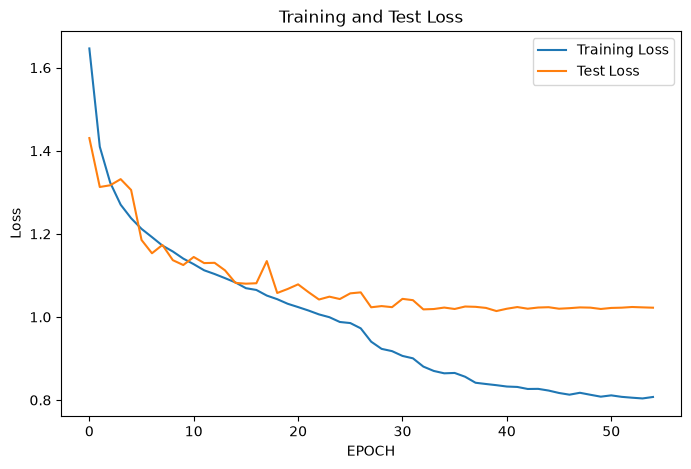

In [53]:
# Loss curve
plt.figure (figsize=(8,5))

plt.plot(train_losses,label="Training Loss")
plt.plot(test_losses,label="Test Loss")

plt.xlabel("EPOCH")
plt.ylabel("Loss")
plt.title("Training and Test Loss")

plt.legend()
plt.show()

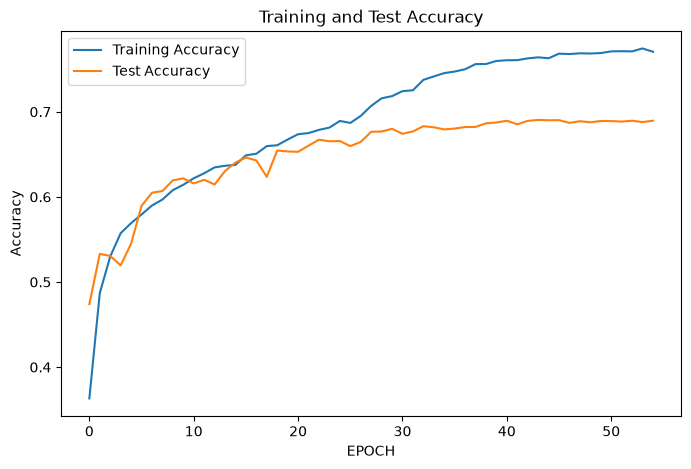

In [54]:
# Accuracy curve
plt.figure(figsize=(8,5))

plt.plot(train_accs,label="Training Accuracy")
plt.plot(test_accs,label="Test Accuracy")

plt.xlabel("EPOCH")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")

plt.legend()
plt.show()


# Confusion Matrix

[[ 589   16   88   38  101  108   18]
 [  16   69    7    4    5    7    3]
 [ 106    7  504   28  111  179   89]
 [  20    3   30 1560   99   29   33]
 [  52    4   61   77  896  122   21]
 [  97    6  146   50  247  682   19]
 [  17    2   69   32   19    7  685]]


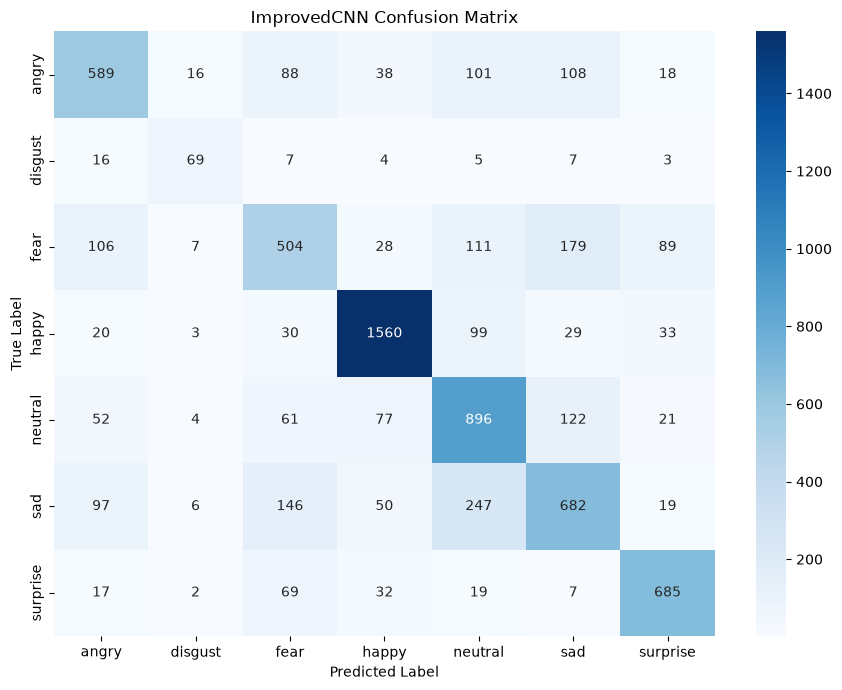

In [ ]:
class_names = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

model.load_state_dict(
    torch.load(
        "best_improved_cnn.pth",
        map_location=device
    )
)

model.eval()

all_predictions = []
all_labels = []

with torch.inference_mode():

    for inputs, labels in test_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs_original = model(inputs)

        outputs_flipped = model(
            torch.flip(inputs, dims=[3])
        )

        outputs = (
            outputs_original + outputs_flipped
        ) / 2

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )
        
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print(cm)

class_names = train_dataset.classes

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("ImprovedCNN Confusion Matrix")

plt.tight_layout()
plt.show()